In [ ]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)





In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
import os

print(os.listdir())

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'archive (4).zip', 'archive (4) (1).zip', 'Telco_customer_churn.xlsx', 'Screenshot (71).png', 'archive (3).zip', 'archive (3) (1).zip', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df.drop('customerID', axis=1, inplace=True)

print(df.shape)

(7043, 20)


In [ ]:
print(df['Churn'].value_counts())

print()

print(df['Churn'].value_counts(normalize=True)*100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


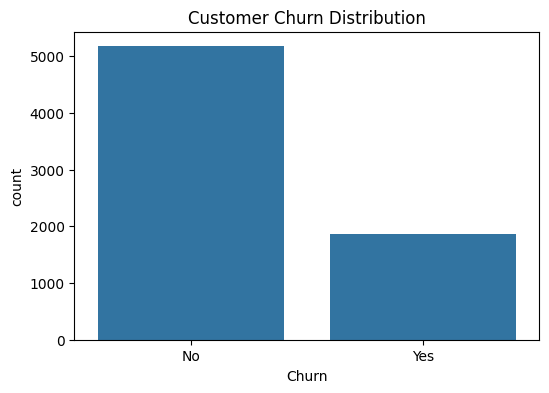

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')

plt.show()

In [ ]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


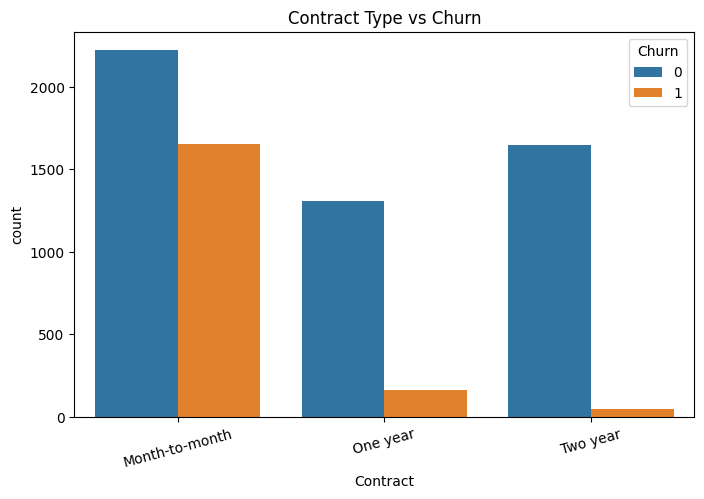

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

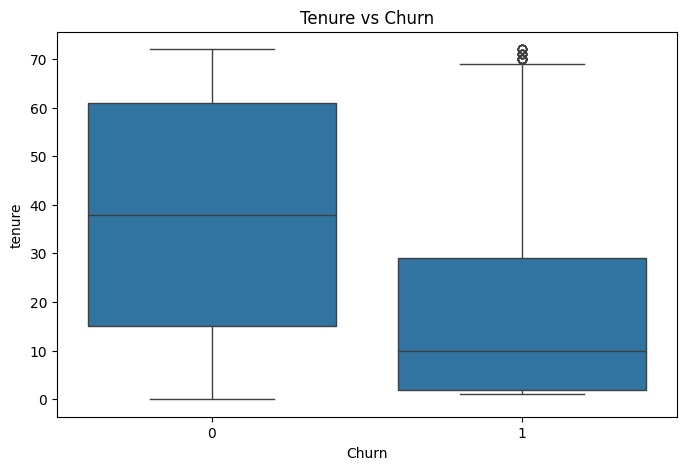

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

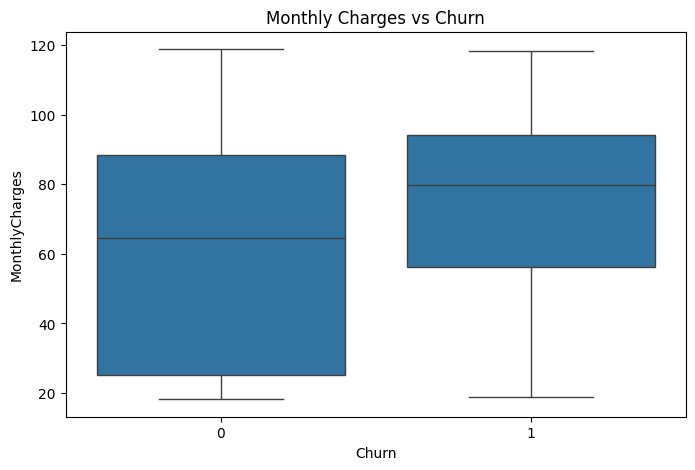

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

temp_df = df.copy()

le = LabelEncoder()

for col in temp_df.columns:

    if temp_df[col].dtype == 'object':

        temp_df[col] = le.fit_transform(temp_df[col])

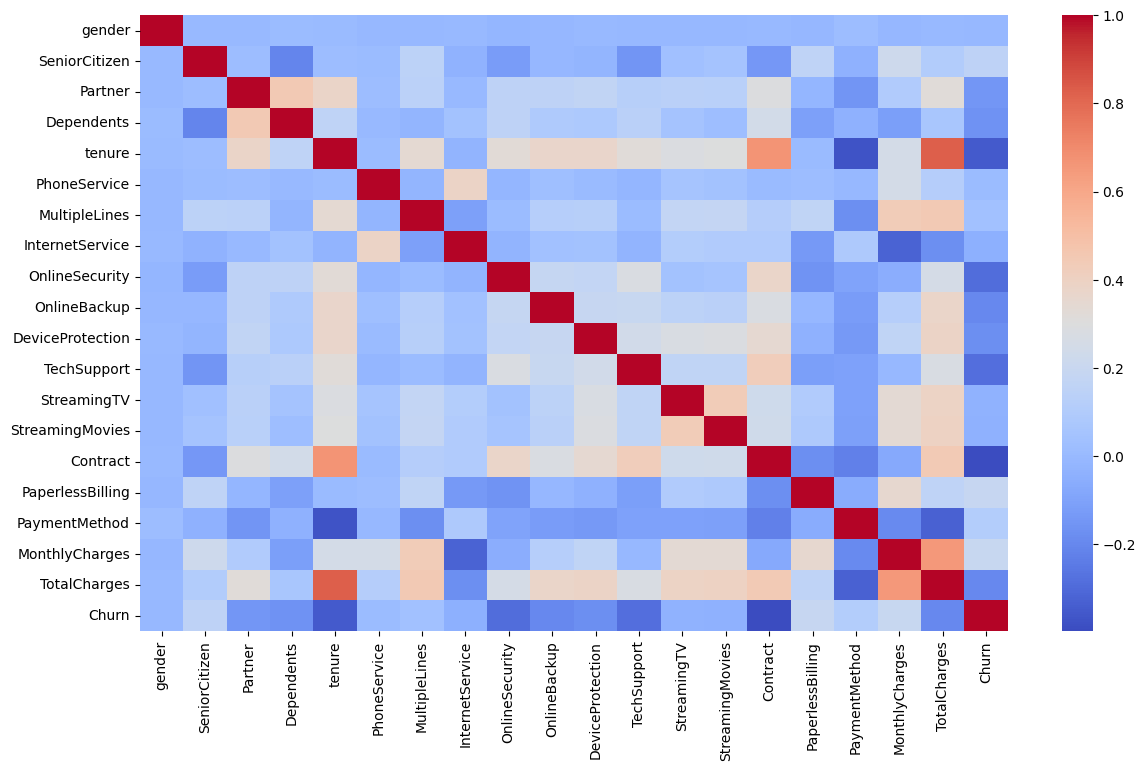

In [ ]:
plt.figure(figsize=(14,8))

sns.heatmap(
    temp_df.corr(),
    cmap='coolwarm'
)

plt.show()

In [ ]:
df['AvgRevenuePerMonth'] = (
    df['TotalCharges'] /
    (df['tenure'] + 1)
)

In [ ]:
df['IsNewCustomer'] = np.where(
    df['tenure'] < 12,
    1,
    0
)

In [ ]:
df['ChargesPerServiceYear'] = (
    df['MonthlyCharges'] *
    12
)


In [ ]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgRevenuePerMonth,IsNewCustomer,ChargesPerServiceYear
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,1,358.2
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,53.985714,0,683.4
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,1,646.2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304,0,507.6
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000,1,848.4


In [ ]:
df_model = pd.get_dummies(
    df,
    drop_first=True
)

print(df_model.shape)

(7043, 34)


In [ ]:
df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgRevenuePerMonth,IsNewCustomer,ChargesPerServiceYear,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,14.925000,1,358.2,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,53.985714,0,683.4,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,36.050000,1,646.2,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,40.016304,0,507.6,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,50.550000,1,848.4,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [ ]:
X = df_model.drop('Churn', axis=1)

y = df_model['Churn']

In [ ]:
print(X.shape)
print(y.shape)

(7043, 33)
(7043,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 33)
(1409, 33)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(y_train.value_counts())

print(y_train_smote.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    4139
1    4139
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr.predict(
    X_test_scaled
)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_lr
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[748 287]
 [ 80 294]]
ROC-AUC: 0.7544007853470769


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_lr
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[748 287]
 [ 80 294]]
ROC-AUC: 0.7544007853470769


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf = rf.predict(
    X_test_scaled
)

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance.head(20)
)

                           Feature  Importance
1                           tenure    0.107668
3                     TotalCharges    0.095058
4               AvgRevenuePerMonth    0.087373
6            ChargesPerServiceYear    0.084204
2                   MonthlyCharges    0.083478
28               Contract_Two year    0.060470
13     InternetService_Fiber optic    0.043957
31  PaymentMethod_Electronic check    0.040486
5                    IsNewCustomer    0.038267
29            PaperlessBilling_Yes    0.034339
22                 TechSupport_Yes    0.033205
16              OnlineSecurity_Yes    0.031506
27               Contract_One year    0.028672
7                      gender_Male    0.023318
8                      Partner_Yes    0.022384
18                OnlineBackup_Yes    0.020163
9                   Dependents_Yes    0.019316
12               MultipleLines_Yes    0.018460
20            DeviceProtection_Yes    0.015927
26             StreamingMovies_Yes    0.014118


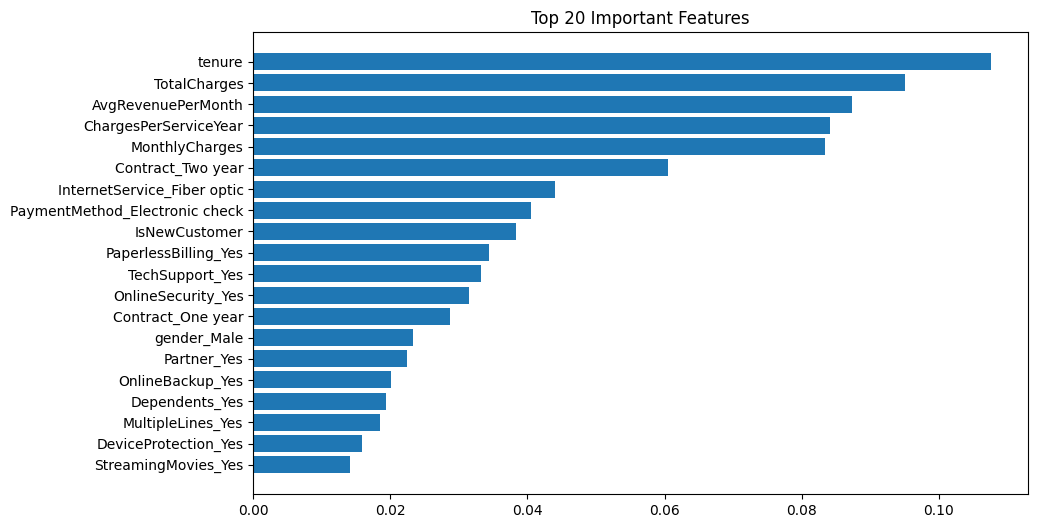

In [ ]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20['Feature'],
    top20['Importance']
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Important Features"
)

plt.show()

In [ ]:
!pip install xgboost shap -q


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test_scaled)

y_prob_xgb = xgb.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(
    y_test,
    y_pred_xgb
))

print()

print(confusion_matrix(
    y_test,
    y_pred_xgb
))

print()

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        y_prob_xgb
    )
)

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.60      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.79      0.78      0.79      1409


[[883 152]
 [151 223]]

ROC AUC: 0.8302203621896717


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
28,Contract_Two year,0.288796
13,InternetService_Fiber optic,0.115641
27,Contract_One year,0.084042
14,InternetService_No,0.045921
5,IsNewCustomer,0.036617
17,OnlineBackup_No internet service,0.036571
15,OnlineSecurity_No internet service,0.035152
26,StreamingMovies_Yes,0.029858
31,PaymentMethod_Electronic check,0.028857
29,PaperlessBilling_Yes,0.023748


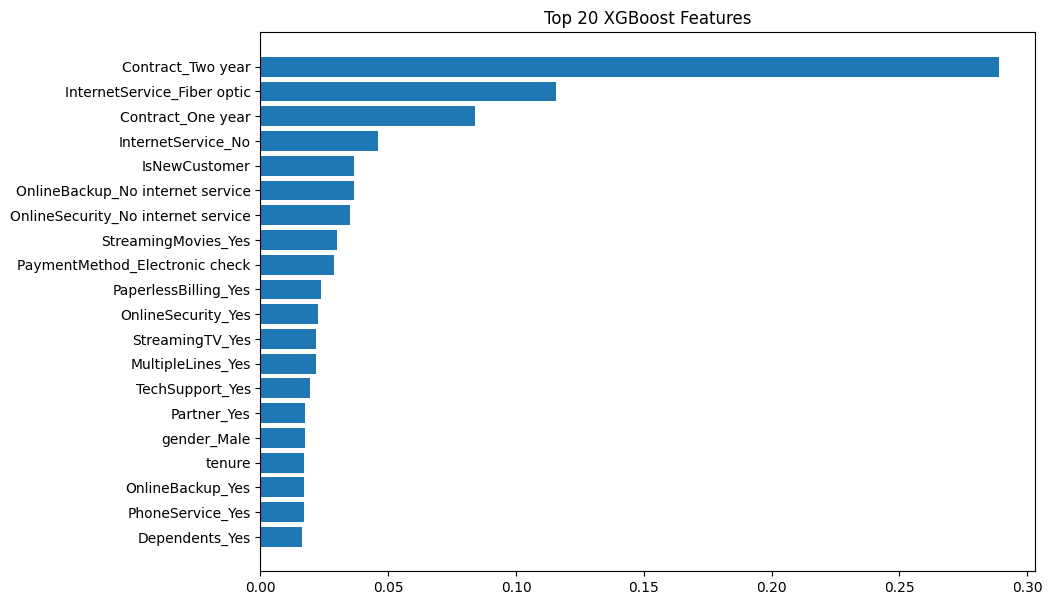

In [ ]:
top20 = importance.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 XGBoost Features"
)

plt.show()

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(
    xgb
)

shap_values = explainer.shap_values(
    X_test_scaled
)

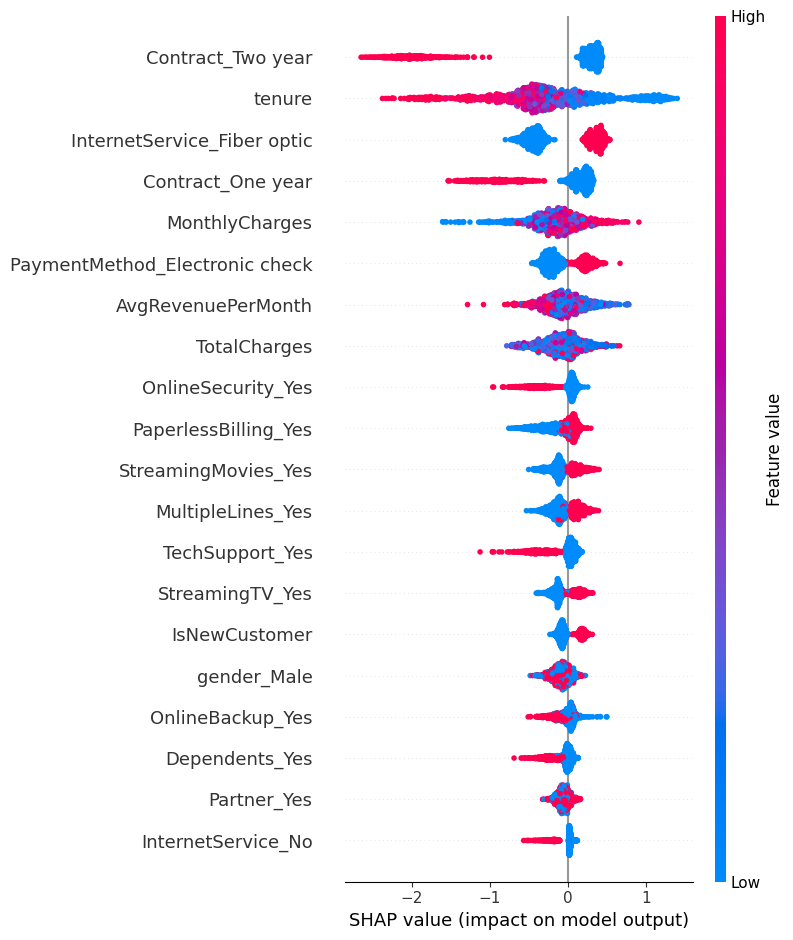

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

In [ ]:
customer_id = 10

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_id],
    X_test_scaled[customer_id],
    feature_names=X.columns
)

In [ ]:
risk_scores = xgb.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
risk_df = pd.DataFrame({
    "RiskScore": risk_scores
})

risk_df.head()

,RiskScore
0,0.005151
1,0.969792
2,0.047425
3,0.265539
4,0.003836


In [ ]:
risk_df["RiskPercent"] = (
    risk_df["RiskScore"] * 100
)

In [ ]:
risk_df["RiskPercent"] = (
    risk_df["RiskScore"] * 100
)

In [ ]:
def risk_level(score):

    if score >= 80:
        return "Critical"

    elif score >= 60:
        return "High"

    elif score >= 40:
        return "Medium"

    else:
        return "Low"

In [ ]:
risk_df["RiskCategory"] = (
    risk_df["RiskPercent"]
    .apply(risk_level)
)

risk_df.head()

,RiskScore,RiskPercent,RiskCategory
0,0.005151,0.515116,Low
1,0.969792,96.979233,Critical
2,0.047425,4.742488,Low
3,0.265539,26.553902,Low
4,0.003836,0.383648,Low


In [ ]:
test_customers = X_test.copy()

test_customers["RiskScore"] = risk_scores

test_customers["ExpectedRevenueLoss"] = (
    test_customers["MonthlyCharges"]
    * test_customers["RiskScore"]
)

In [ ]:
print(
    "Revenue At Risk = $",
    round(
        test_customers[
            "ExpectedRevenueLoss"
        ].sum(),
        2
    )
)

Revenue At Risk = $ 29731.43


In [ ]:
seg_df = df.copy()

seg_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'AvgRevenuePerMonth'
]

seg_df = seg_df[seg_features]

seg_df.head()

,tenure,MonthlyCharges,TotalCharges,AvgRevenuePerMonth
0,1,29.85,29.85,14.925000
1,34,56.95,1889.50,53.985714
2,2,53.85,108.15,36.050000
3,45,42.30,1840.75,40.016304
4,2,70.70,151.65,50.550000


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_seg = StandardScaler()

seg_scaled = scaler_seg.fit_transform(
    seg_df
)

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(seg_scaled)

    wcss.append(km.inertia_)

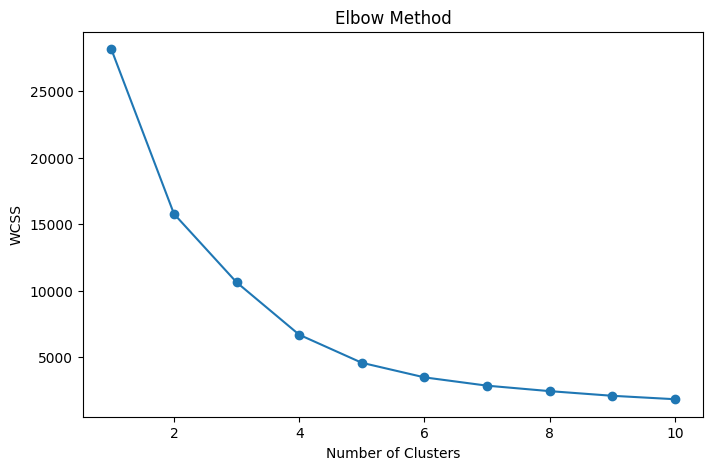

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    seg_scaled
)

In [ ]:
df['Cluster'] = clusters

df[['tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Cluster']].head()

,tenure,MonthlyCharges,TotalCharges,Cluster
0,1,29.85,29.85,1
1,34,56.95,1889.50,2
2,2,53.85,108.15,2
3,45,42.30,1840.75,1
4,2,70.70,151.65,2


In [ ]:
cluster_summary = df.groupby(
    'Cluster'
).agg({
    'tenure':'mean',
    'MonthlyCharges':'mean',
    'TotalCharges':'mean',
    'Churn':'mean'
})

cluster_summary

,tenure,MonthlyCharges,TotalCharges,Churn
Cluster,,,,
0,58.839335,89.903116,5281.260711,0.151431
1,26.717652,28.861203,740.696631,0.161224
2,14.676747,78.102002,1154.561851,0.470372
3,0.000000,41.418182,1397.475000,0.000000


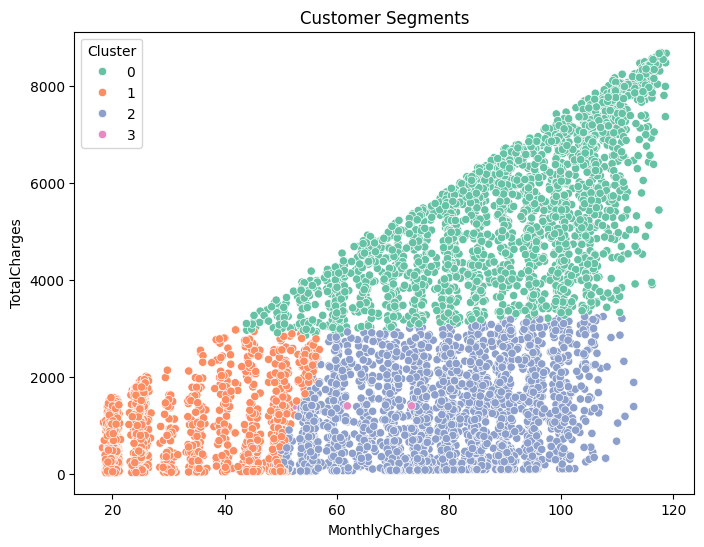

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Cluster',
    palette='Set2'
)

plt.title(
    "Customer Segments"
)

plt.show()

In [ ]:
cluster_names = {
    0:'Premium Customers',
    1:'High Risk Customers',
    2:'New Customers',
    3:'Loyal Customers'
}

df['Segment'] = (
    df['Cluster']
    .map(cluster_names)
)

In [ ]:
df['Segment'].value_counts()

,count
Segment,
New Customers,2447
High Risk Customers,2419
Premium Customers,2166
Loyal Customers,11


In [ ]:
def recommendation(segment):

    if segment == 'High Risk Customers':
        return 'Offer retention discount'

    elif segment == 'Premium Customers':
        return 'Provide VIP benefits'

    elif segment == 'New Customers':
        return 'Onboarding campaign'

    else:
        return 'Loyalty rewards'

In [ ]:
df['Recommendation'] = (
    df['Segment']
    .apply(recommendation)
)

In [ ]:
risk_scores

array([0.00515116, 0.96979237, 0.04742488, ..., 0.11160672, 0.1475446 ,
       0.00504245], dtype=float32)

In [ ]:
risk_output = pd.DataFrame({
    'ActualChurn': y_test,
    'RiskScore': risk_scores
})

risk_output.head()

,ActualChurn,RiskScore
437,0,0.005151
2280,0,0.969792
2235,0,0.047425
4460,0,0.265539
3761,0,0.003836


In [ ]:
df.to_csv(
    "customer_intelligence_output.csv",
    index=False
)

print(
    "Customer Intelligence Dataset Saved"
)

Customer Intelligence Dataset Saved


In [ ]:
# ======================================================
# Generate Predictions for ALL Customers
# ======================================================

X_full = df_model.drop('Churn', axis=1)

X_full_scaled = scaler.transform(X_full)

all_probabilities = xgb.predict_proba(
    X_full_scaled
)[:,1]

In [ ]:
# ======================================================
# Customer Intelligence Dataset
# ======================================================

customer_intelligence = df.copy()

customer_intelligence['ChurnProbability'] = all_probabilities

customer_intelligence['ChurnProbabilityPercent'] = (
    all_probabilities * 100
)

In [ ]:
customer_intelligence[
    'ChurnProbabilityPercent'
] = (
    customer_intelligence[
        'ChurnProbability'
    ] * 100
)

In [ ]:
def risk_category(prob):

    if prob >= 80:
        return "Critical"

    elif prob >= 60:
        return "High"

    elif prob >= 40:
        return "Medium"

    else:
        return "Low"

In [ ]:
customer_intelligence[
    'RiskCategory'
] = (
    customer_intelligence[
        'ChurnProbabilityPercent'
    ]
    .fillna(0)
    .apply(risk_category)
)

In [ ]:
customer_intelligence[
    'RevenueAtRisk'
] = (
    customer_intelligence[
        'MonthlyCharges'
    ] *
    customer_intelligence[
        'ChurnProbability'
    ].fillna(0)
)

In [ ]:
customer_intelligence[
    'EstimatedCLV'
] = (
    customer_intelligence[
        'MonthlyCharges'
    ]
    *
    customer_intelligence[
        'tenure'
    ]
)

In [ ]:
customer_intelligence[
    'PriorityScore'
] = (
    customer_intelligence[
        'RevenueAtRisk'
    ]
    *
    customer_intelligence[
        'EstimatedCLV'
    ]
)

In [ ]:
top_customers = (
    customer_intelligence
    .sort_values(
        by='PriorityScore',
        ascending=False
    )
)

top_customers.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgRevenuePerMonth,IsNewCustomer,ChargesPerServiceYear,Cluster,Segment,Recommendation,ChurnProbability,ChurnProbabilityPercent,RiskCategory,RevenueAtRisk,EstimatedCLV,PriorityScore
6408,Male,0,No,No,69,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),106.50,7348.80,1,104.982857,0,1278.0,0,Premium Customers,Provide VIP benefits,0.942535,94.253479,Critical,100.379957,7348.50,737642.111536
5697,Female,0,Yes,No,70,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,109.50,7674.55,1,108.092254,0,1314.0,0,Premium Customers,Provide VIP benefits,0.785493,78.549301,High,86.011485,7665.00,659278.034661
6032,Male,1,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.30,7299.65,1,105.792029,0,1263.6,0,Premium Customers,Provide VIP benefits,0.852243,85.224297,Critical,89.741182,7160.40,642582.761595
4395,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.95,7446.90,1,106.384286,0,1247.4,0,Premium Customers,Provide VIP benefits,0.851330,85.133018,Critical,88.495776,7172.55,634740.381317
2879,Male,1,Yes,No,70,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,102.95,7101.50,1,100.021127,0,1235.4,0,Premium Customers,Provide VIP benefits,0.851446,85.144638,Critical,87.656406,7206.50,631695.888874
5050,Male,0,Yes,No,66,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),106.05,6981.35,1,104.199254,0,1272.6,0,Premium Customers,Provide VIP benefits,0.849728,84.972816,Critical,90.113672,6999.30,630732.625244
6016,Male,0,No,No,68,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,No,Electronic check,108.45,7176.55,1,104.007971,0,1301.4,0,Premium Customers,Provide VIP benefits,0.783904,78.390411,High,85.014397,7374.60,626947.172126
1339,Male,0,Yes,No,66,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),105.00,7133.25,1,106.466418,0,1260.0,0,Premium Customers,Provide VIP benefits,0.833478,83.347824,Critical,87.515219,6930.00,606480.464593
3890,Female,0,Yes,No,72,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,109.25,8109.80,1,111.093151,0,1311.0,0,Premium Customers,Provide VIP benefits,0.698664,69.866402,High,76.329043,7866.00,600404.252597
1306,Female,0,No,No,70,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),115.55,8127.60,1,114.473239,0,1386.6,0,Premium Customers,Provide VIP benefits,0.636556,63.655643,High,73.554097,8088.50,594942.316813


In [ ]:
total_customers = len(customer_intelligence)

critical_customers = (
    customer_intelligence[
        customer_intelligence[
            'RiskCategory'
        ] == 'Critical'
    ]
).shape[0]

total_revenue_risk = (
    customer_intelligence[
        'RevenueAtRisk'
    ].sum()
)

avg_churn_prob = (
    customer_intelligence[
        'ChurnProbabilityPercent'
    ].mean()
)

print("Customers:", total_customers)

print("Critical Risk:", critical_customers)

print("Revenue At Risk:", round(total_revenue_risk,2))

print("Average Churn Probability:", round(avg_churn_prob,2))

Customers: 7043
Critical Risk: 751
Revenue At Risk: 149189.04
Average Churn Probability: 28.66


In [ ]:
all_probabilities = xgb.predict_proba(
    scaler.transform(X)
)[:,1]

In [ ]:
customer_intelligence.to_csv(
    "Customer_Intelligence_Dashboard.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "Customer_Intelligence_Dashboard.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(customer_intelligence.isnull().sum())

gender                     0
SeniorCitizen              0
Partner                    0
Dependents                 0
tenure                     0
PhoneService               0
MultipleLines              0
InternetService            0
OnlineSecurity             0
OnlineBackup               0
DeviceProtection           0
TechSupport                0
StreamingTV                0
StreamingMovies            0
Contract                   0
PaperlessBilling           0
PaymentMethod              0
MonthlyCharges             0
TotalCharges               0
Churn                      0
AvgRevenuePerMonth         0
IsNewCustomer              0
ChargesPerServiceYear      0
Cluster                    0
Segment                    0
Recommendation             0
ChurnProbability           0
ChurnProbabilityPercent    0
RiskCategory               0
RevenueAtRisk              0
EstimatedCLV               0
PriorityScore              0
dtype: int64


In [ ]:
customer_intelligence.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   7043 non-null   object 
 1   SeniorCitizen            7043 non-null   int64  
 2   Partner                  7043 non-null   object 
 3   Dependents               7043 non-null   object 
 4   tenure                   7043 non-null   int64  
 5   PhoneService             7043 non-null   object 
 6   MultipleLines            7043 non-null   object 
 7   InternetService          7043 non-null   object 
 8   OnlineSecurity           7043 non-null   object 
 9   OnlineBackup             7043 non-null   object 
 10  DeviceProtection         7043 non-null   object 
 11  TechSupport              7043 non-null   object 
 12  StreamingTV              7043 non-null   object 
 13  StreamingMovies          7043 non-null   object 
 14  Contract                